In [16]:
import sys
!{sys.executable} -m pip install pandas scikit-image skan

In [17]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import color, filters
from skimage.morphology import skeletonize, closing, remove_small_objects, disk

try:
    from skan import Skeleton, summarize
    SKAN_AVAILABLE = True
    print('✅ skan available')
except ImportError:
    SKAN_AVAILABLE = False
    print('⚠️ skan not installed — branch stats skipped')

✅ skan available


In [22]:
VIDEO_PATH      = Path(r'C:\Users\xiaoh\OneDrive\Desktop\Final_morphogenesis\05_shared_data\input\ice_crystal_01_resized.mp4')
OUTPUT_DIR      = Path(r'C:\Users\xiaoh\OneDrive\Desktop\Final_morphogenesis\09_experiments\previous_tests\01_material_analysis\output\ice_crystal_01\skeletons')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INVERT_BINARY   = False   # 已经在函数里处理了，这行无所谓
CLOSING_RADIUS  = 1       # 改小一点，保留更多细节
MIN_OBJECT_SIZE = 32

In [19]:
def binarize(image, invert=INVERT_BINARY):
    gray   = color.rgb2gray(image) if image.ndim == 3 else image.astype(float)
    thresh = filters.threshold_otsu(gray)
    binary = gray > thresh
    if invert:
        binary = ~binary
    binary = closing(binary, disk(CLOSING_RADIUS))
    binary = remove_small_objects(binary, min_size=MIN_OBJECT_SIZE)
    return binary

def extract_skeleton(binary, method='lee'):
    return skeletonize(binary, method=method)

def compute_features(skeleton, name):
    features = {
        'filename':        name,
        'skeleton_pixels': int(skeleton.sum()),
        'image_area':      int(skeleton.size),
        'density':         round(skeleton.sum() / skeleton.size, 6),
    }
    if SKAN_AVAILABLE and skeleton.sum() > 0:
        try:
            skel_obj = Skeleton(skeleton)
            stats    = summarize(skel_obj)
            features.update({
                'n_branches':      len(stats),
                'total_length':    round(stats['branch-distance'].sum(), 2),
                'mean_branch_len': round(stats['branch-distance'].mean(), 2),
                'n_endpoints':     int((stats['branch-type'] == 1).sum()),
                'n_junctions':     int((stats['branch-type'] == 2).sum()),
            })
        except Exception as e:
            print(f'skan error for {name}: {e}')
    return features

print('✅ Functions loaded')

✅ Functions loaded


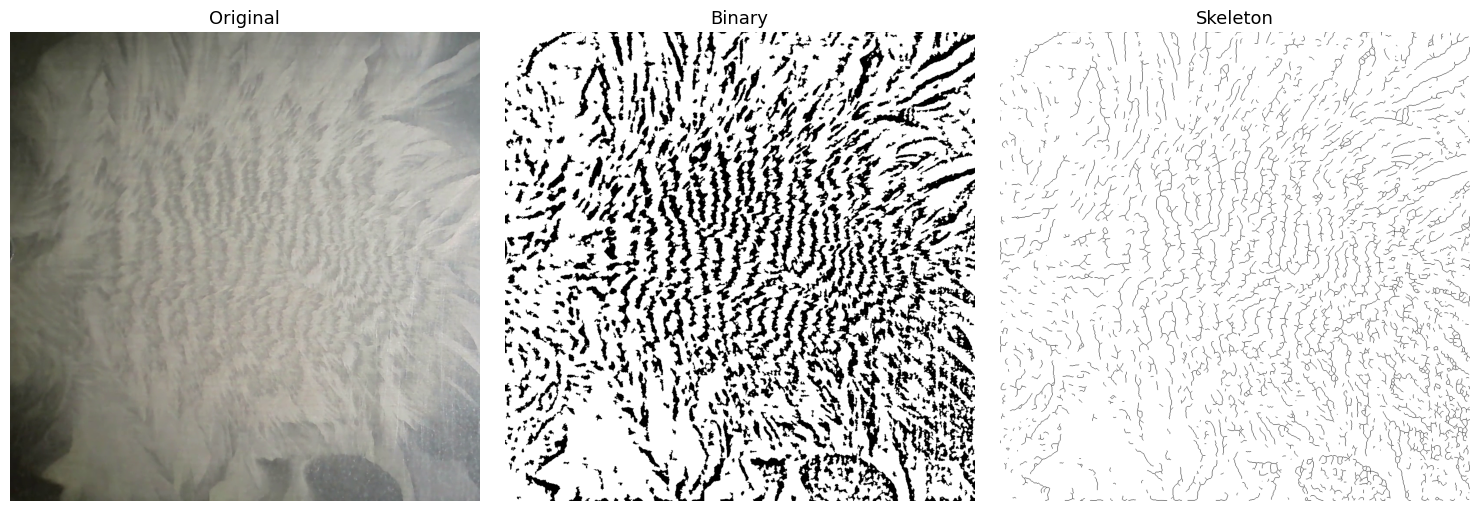

In [30]:
TARGET_FRAME = 400

cap = cv2.VideoCapture(str(VIDEO_PATH))
cap.set(cv2.CAP_PROP_POS_FRAMES, TARGET_FRAME)
ret, frame = cap.read()
cap.release()

image    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
binary   = binarize(image)
def binarize(image, invert=INVERT_BINARY):
    from skimage.filters import threshold_local
    
    gray = color.rgb2gray(image) if image.ndim == 3 else image.astype(float)
    
    # 局部自适应阈值 — block_size 控制感知范围，越小越细节
    thresh = threshold_local(gray, block_size=51, offset=0.01)
    binary = gray < thresh   # 亮背景下晶体是暗的
    
    binary = closing(binary, disk(CLOSING_RADIUS))
    binary = remove_small_objects(binary, min_size=MIN_OBJECT_SIZE)
    return binary
skeleton = extract_skeleton(binary)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('white')
for ax, im, title, cmap in zip(
    axes,
    [image, binary, skeleton],
    ['Original', 'Binary', 'Skeleton'],
    [None, 'gray_r', 'gray_r']
):
    ax.imshow(im, cmap=cmap)
    ax.set_title(title, color='black', fontsize=13)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [28]:
import cv2
import numpy as np
from pathlib import Path
from skimage import color, filters
from skimage.filters import threshold_local
from skimage.morphology import skeletonize, closing, remove_small_objects, disk

VIDEO_PATH  = Path(r'C:\Users\xiaoh\OneDrive\Desktop\Final_morphogenesis\05_shared_data\input\ice_crystal_01_resized.mp4')
OUTPUT_PATH = Path(r'C:\Users\xiaoh\OneDrive\Desktop\Final_morphogenesis\09_experiments\previous_tests\01_material_analysis\output\ice_crystal_01\skeleton.mp4')
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

CLOSING_RADIUS  = 1
MIN_OBJECT_SIZE = 32

cap    = cv2.VideoCapture(str(VIDEO_PATH))
fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(str(OUTPUT_PATH),
                      cv2.VideoWriter_fourcc(*'mp4v'),
                      fps, (width, height))

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray   = color.rgb2gray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    thresh = threshold_local(gray, block_size=51, offset=0.01)
    binary = gray < thresh
    binary = closing(binary, disk(CLOSING_RADIUS))
    binary = remove_small_objects(binary, min_size=MIN_OBJECT_SIZE)
    skel   = skeletonize(binary)

    out_frame = ((~skel) * 255).astype(np.uint8)
    out_frame = cv2.cvtColor(out_frame, cv2.COLOR_GRAY2BGR)
    out.write(out_frame)

    if frame_idx % 100 == 0:
        print(f'  {frame_idx}/{total}')
    frame_idx += 1

cap.release()
out.release()
print(f'\n✅ Saved to {OUTPUT_PATH}')

  0/701
  100/701
  200/701
  300/701
  400/701
  500/701
  600/701
  700/701

✅ Saved to C:\Users\xiaoh\OneDrive\Desktop\Final_morphogenesis\09_experiments\previous_tests\01_material_analysis\output\ice_crystal_01\skeleton.mp4


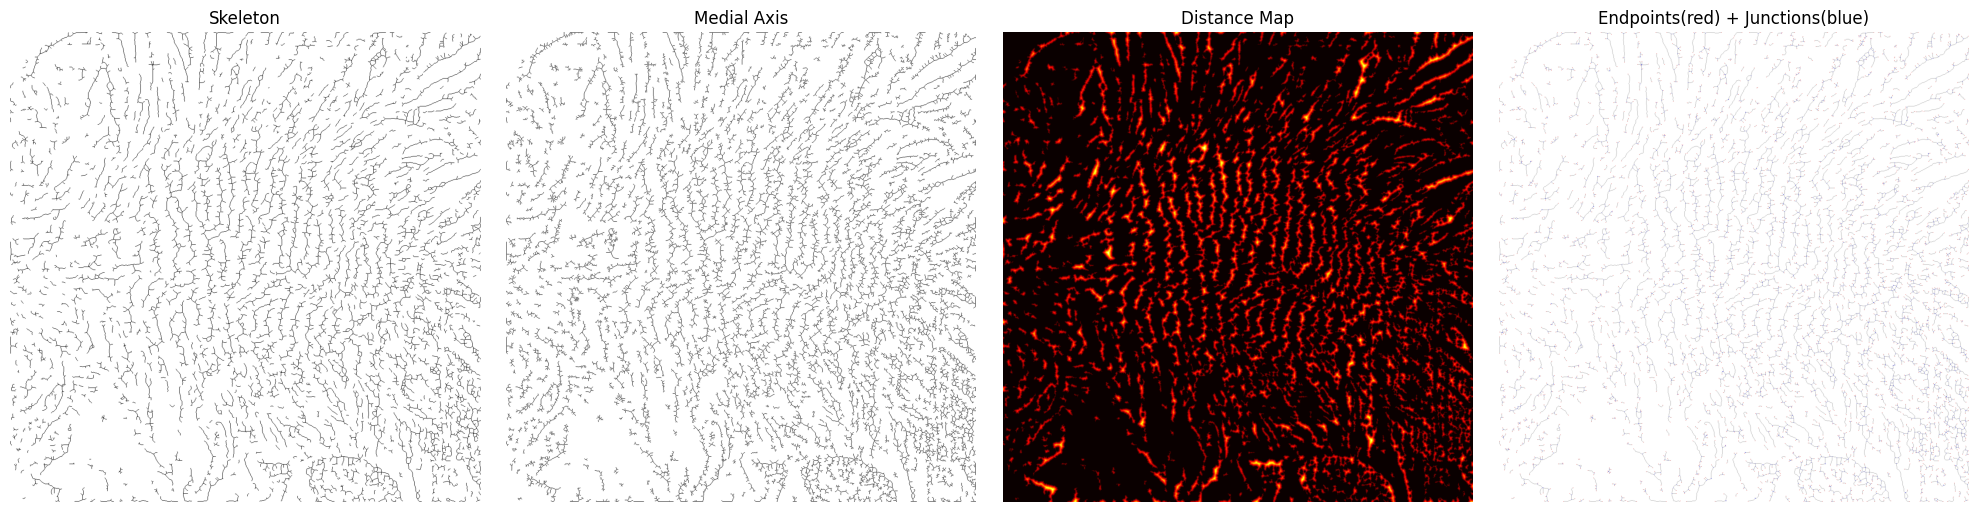

In [32]:
from skimage.morphology import medial_axis
import numpy as np

skeleton  = skeletonize(binary)
medial, distance = medial_axis(binary, return_distance=True)

if SKAN_AVAILABLE:
    from skan import Skeleton
    skel_obj      = Skeleton(skeleton)
    coords        = skel_obj.coordinates
    endpoint_mask = np.zeros(skeleton.shape, bool)
    junction_mask = np.zeros(skeleton.shape, bool)
    
    for i, degree in enumerate(skel_obj.degrees):
        r, c = int(coords[i, 0]), int(coords[i, 1])
        if degree == 1:
            endpoint_mask[r, c] = True
        elif degree >= 3:
            junction_mask[r, c] = True

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor('white')

axes[0].imshow(skeleton,  cmap='gray_r');  axes[0].set_title('Skeleton',    color='black')
axes[1].imshow(medial,    cmap='gray_r');  axes[1].set_title('Medial Axis', color='black')
axes[2].imshow(distance,  cmap='hot');     axes[2].set_title('Distance Map',color='black')

if SKAN_AVAILABLE:
    overlay = np.ones((*skeleton.shape, 3))
    overlay[skeleton]      = [0.7, 0.7, 0.7]
    overlay[endpoint_mask] = [0.9, 0.2, 0.2]
    overlay[junction_mask] = [0.2, 0.2, 0.9]
    axes[3].imshow(overlay)
    axes[3].set_title('Endpoints(red) + Junctions(blue)', color='black')

for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()